# Deep Networks with Stochastic Depth — Replication Study
**Paper**: G. Huang, Y. Sun, Z. Liu, D. Sedra, and K. Q. Weinberger, “Deep networks with stochastic depth,”([arXiv:1603.09382](https://arxiv.org/abs/1603.09382))  
**Course**: CS 5782 Final Project  
**Students**: Jin Fan(jf936), Yixuan Yang(yy2445), Youlun Jiang(yj622)

In [ ]:
import torch, subprocess, sys

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Memory: {mem_gb:.1f} GB")
else:
    print("WARNING: No GPU. Please enable GPU in Runtime → Change runtime type.")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


## Setup: Google Drive

In [ ]:
import os

MOUNT_DRIVE = True

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results'
else:
    SAVE_DIR = '/content/stochastic_depth_results'

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoints/results → {SAVE_DIR}")

Mounted at /content/drive
Checkpoints/results → /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results


In [ ]:
import os, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Hyperparameters

In [ ]:
# Architecture
N_BLOCKS_PER_GROUP = 18
N_GROUPS = 3
L = N_BLOCKS_PER_GROUP * N_GROUPS
P_L = 0.5

# Training
EPOCHS = 500
BATCH_SIZE = 128
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
LR_MILESTONES = [250, 375]
LR_GAMMA      = 0.1

# Data split
N_TRAIN = 45_000
N_VAL =  5_000

CHECKPOINT_FREQ = 10

def survival_probs(n_per_group=N_BLOCKS_PER_GROUP, n_groups=N_GROUPS, p_L=P_L):
    """Linear decay rule: p_l = 1 - (l/L)*(1 - p_L), l = 1..L"""
    total = n_per_group * n_groups
    return [1.0 - (l / total) * (1.0 - p_L) for l in range(1, total + 1)]

probs = survival_probs()
print(f"Total blocks L = {L}")
print(f"p_1 = {probs[0]:.4f} (paper ≈ 0.9907)")
print(f"p_L = {probs[-1]:.4f} (paper = 0.5)")
print(f"Mean survival prob = {sum(probs)/len(probs):.4f}  → ~{100*(1-sum(probs)/len(probs)):.0f}% blocks dropped on avg")

Total blocks L = 54
p_1 = 0.9907 (paper ≈ 0.9907)
p_L = 0.5000 (paper = 0.5)
Mean survival prob = 0.7454  → ~25% blocks dropped on avg


## CIFAR-10 Data Loading

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),])

def get_dataloaders(noise_rate=0.0, seed=42):
  full_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
  test_set   = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)

  train_set, val_set = random_split(
      full_train, [N_TRAIN, N_VAL],
      generator=torch.Generator().manual_seed(SEED)
  )

  if noise_rate > 0:
    rng = np.random.RandomState(seed)
    targets = np.array(full_train.targets)
    train_indices = train_set.indices

    n_noisy = int(noise_rate * len(train_indices))
    noisy_idx = rng.choice(train_indices, n_noisy, replace=False)

    for idx in noisy_idx:
        original = targets[idx]
        new_label = rng.choice([c for c in range(10) if c != original])
        targets[idx] = new_label

    full_train.targets = targets.tolist()
    print(f"Corrupted {n_noisy}/{len(train_indices)} training labels ({noise_rate*100:.0f}%)")

  print(f"Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}")

  train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
  val_loader = DataLoader(val_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
  test_loader = DataLoader(test_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
  return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders()
print(f"Steps per epoch: {len(train_loader)}")

100%|██████████| 170M/170M [03:03<00:00, 930kB/s]


Train: 45,000 | Val: 5,000 | Test: 10,000
Steps per epoch: 352


## Model Architecture

**110-layer ResNet** for CIFAR-10 (He et al. 2016):  
- Initial 3×3 conv → 16 filters  
- Group 1: 18 blocks × 16 filters (stride 1)  
- Group 2: 18 blocks × 32 filters (stride 2 at first block)  
- Group 3: 18 blocks × 64 filters (stride 2 at first block)  
- Global avg pool → FC(64, 10)  

**Stochastic depth**: each block samples `b_l ~ Bernoulli(p_l)` per mini-batch.  


In [ ]:
class ShortcutProjection(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.stride   = stride
        self.in_ch    = in_ch
        self.out_ch   = out_ch

    def forward(self, x):
        if self.stride > 1:
            x = F.avg_pool2d(x, self.stride)
        if self.in_ch != self.out_ch:
            pad = self.out_ch - self.in_ch   # all zeros appended at end of channel dim
            x = F.pad(x, (0, 0, 0, 0, 0, pad))
        return x


def _make_shortcut(in_ch, out_ch, stride):
    if stride == 1 and in_ch == out_ch:
        return nn.Sequential()
    return ShortcutProjection(in_ch, out_ch, stride)


class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = _make_shortcut(in_ch, out_ch, stride)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x), inplace=True)


class StochasticBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, p_survive=1.0):
        super().__init__()
        self.p = p_survive
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = _make_shortcut(in_ch, out_ch, stride)

    def forward(self, x):
        identity = self.shortcut(x)
        if self.training:
            if self.p < 1.0 and torch.rand(1).item() > self.p:
                return identity  # block dropped, no ReLU (identity already non-negative)
            out = F.relu(self.bn1(self.conv1(x)), inplace=True)
            out = self.bn2(self.conv2(out))
            return F.relu(out + identity, inplace=True)
        else:
            out = F.relu(self.bn1(self.conv1(x)), inplace=True)
            out = self.bn2(self.conv2(out))
            return F.relu(self.p * out + identity, inplace=True)

In [ ]:
def _init_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.01)
            nn.init.constant_(m.bias, 0)


class ResNet110(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv0 = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn0   = nn.BatchNorm2d(16)
        self.group1 = self._make_group(BasicBlock, 16, 16, N_BLOCKS_PER_GROUP, stride=1)
        self.group2 = self._make_group(BasicBlock, 16, 32, N_BLOCKS_PER_GROUP, stride=2)
        self.group3 = self._make_group(BasicBlock, 32, 64, N_BLOCKS_PER_GROUP, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(64, num_classes)
        _init_weights(self)

    @staticmethod
    def _make_group(block_cls, in_ch, out_ch, n, stride, probs=None):
        layers = [block_cls(in_ch, out_ch, stride=stride,
                            **({'p_survive': probs[0]} if probs else {}))]
        for i in range(1, n):
            kw = {'p_survive': probs[i]} if probs else {}
            layers.append(block_cls(out_ch, out_ch, stride=1, **kw))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn0(self.conv0(x)), inplace=True)
        x = self.group1(x)
        x = self.group2(x)
        x = self.group3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


class ResNet110_SD(ResNet110):
    def __init__(self, num_classes=10, p_L=P_L):
        nn.Module.__init__(self)
        probs = survival_probs(p_L=p_L)
        g1 = probs[0  : N_BLOCKS_PER_GROUP]
        g2 = probs[N_BLOCKS_PER_GROUP : 2*N_BLOCKS_PER_GROUP]
        g3 = probs[2*N_BLOCKS_PER_GROUP : 3*N_BLOCKS_PER_GROUP]

        self.conv0  = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn0 = nn.BatchNorm2d(16)
        self.group1 = self._make_group(StochasticBlock, 16, 16, N_BLOCKS_PER_GROUP, stride=1, probs=g1)
        self.group2 = self._make_group(StochasticBlock, 16, 32, N_BLOCKS_PER_GROUP, stride=2, probs=g2)
        self.group3 = self._make_group(StochasticBlock, 32, 64, N_BLOCKS_PER_GROUP, stride=2, probs=g3)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)
        _init_weights(self)


#Params check
_x = torch.randn(4, 3, 32, 32)
_cd = ResNet110()
_sd = ResNet110_SD()
assert _cd(_x).shape == (4, 10)
assert _sd(_x).shape == (4, 10)
n_cd = sum(p.numel() for p in _cd.parameters())
n_sd = sum(p.numel() for p in _sd.parameters())
print(f"ResNet-110 params: {n_cd:,}")
print(f"ResNet-110-SD params: {n_sd:,}")
print("Params check passed.")

ResNet-110 params: 1,727,962
ResNet-110-SD params: 1,727,962
Params check passed.


## Survival Probability Schedule (Linear Decay Rule)

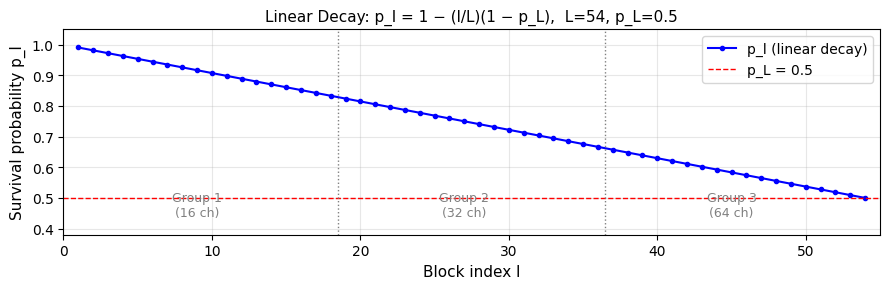

In [ ]:
probs_plot = survival_probs()
block_idx  = list(range(1, L + 1))

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(block_idx, probs_plot, 'b-o', ms=3, lw=1.5, label='p_l (linear decay)')
ax.axhline(P_L, color='red', ls='--', lw=1, label=f'p_L = {P_L}')

for bnd in [N_BLOCKS_PER_GROUP, 2*N_BLOCKS_PER_GROUP]:
    ax.axvline(bnd + 0.5, color='gray', ls=':', lw=1)

for mid, lbl in [(9, 'Group 1\n(16 ch)'), (27, 'Group 2\n(32 ch)'), (45, 'Group 3\n(64 ch)')]:
    ax.text(mid, 0.44, lbl, ha='center', fontsize=9, color='gray')

ax.set_xlabel('Block index l', fontsize=11)
ax.set_ylabel('Survival probability p_l', fontsize=11)
ax.set_title(f'Linear Decay: p_l = 1 − (l/L)(1 − p_L),  L={L}, p_L={P_L}', fontsize=11)
ax.set_ylim(0.38, 1.05);  ax.set_xlim(0, L+1)
ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'survival_probs.png'), dpi=150, bbox_inches='tight')
plt.show()

## Training Utilities

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    grad_mag = 0.0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        if model.conv0.weight.grad is not None:
            grad_mag = model.conv0.weight.grad.abs().mean().item()

        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct += outputs.argmax(1).eq(targets).sum().item()
        total += inputs.size(0)

    return total_loss / total, 100.0 * (1 - correct / total), grad_mag

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        correct += outputs.argmax(1).eq(targets).sum().item()
        total += inputs.size(0)
    return total_loss / total, 100.0 * (1 - correct / total)

In [ ]:
def fmt_duration(sec):
    sec = max(0, int(sec))
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    if h:
        return f"{h}h {m}m"
    if m:
        return f"{m}m {s}s"
    return f"{s}s"


def completed_training_seconds(name):
    history_path = os.path.join(SAVE_DIR, name, 'history.json')
    if not os.path.exists(history_path):
        return 0.0, 0
    try:
        with open(history_path) as f:
            hist = json.load(f)
        return float(hist.get('total_sec', 0.0)), len(hist.get('epoch_sec', []))
    except Exception:
        return 0.0, 0


def estimate_epoch_seconds(model_cls, benchmark_batches=40, warmup_batches=5, **model_kwargs):
    """Estimate one full epoch by timing a small representative training pass."""
    train_loader, val_loader, test_loader = get_dataloaders()
    model = model_cls(**model_kwargs).to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
    criterion = nn.CrossEntropyLoss()
    model.train()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    timed_batches = 0
    t0 = None

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(inputs), targets)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        if batch_idx + 1 == warmup_batches:
            t0 = time.time()
        elif batch_idx + 1 > warmup_batches:
            timed_batches += 1
            if timed_batches >= benchmark_batches:
                break

    if t0 is None or timed_batches == 0:
        return None
    train_sec_per_batch = (time.time() - t0) / timed_batches
    train_sec = train_sec_per_batch * len(train_loader)
    eval_t0 = time.time()
    evaluate(model, val_loader, criterion)
    evaluate(model, test_loader, criterion)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    eval_sec = time.time() - eval_t0
    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return train_sec + eval_sec


def estimate_full_runtime(benchmark_batches=40, warmup_batches=5):
    print("\nEstimating runtime on the current machine...\n")
    specs = [
        ('constant_depth', 'Constant depth', ResNet110, {}),
        ('stochastic_depth', 'Stochastic depth', ResNet110_SD, {'p_L': P_L}),
    ]

    total_remaining_sec = 0.0
    for run_name, label, model_cls, kwargs in specs:
        done_sec, done_epochs = completed_training_seconds(run_name)
        remaining_epochs = max(0, EPOCHS - done_epochs)

        epoch_sec = estimate_epoch_seconds(
            model_cls,
            benchmark_batches=benchmark_batches,
            warmup_batches=warmup_batches,
            **kwargs,
        )

        if epoch_sec is None:
            print(f"{label}: unable to estimate.")
            continue

        remaining_sec = epoch_sec * remaining_epochs
        total_remaining_sec += remaining_sec

        print(f"{label}: ~{fmt_duration(epoch_sec)} / epoch")
        print(f" completed: {done_epochs}/{EPOCHS} epochs ({fmt_duration(done_sec)} recorded)")
        print(f" remaining: ~{fmt_duration(remaining_sec)}")

    print(f"\nEstimated remaining time for both full experiments: ~{fmt_duration(total_remaining_sec)}")
    print("This is a live estimate from a short benchmark; data download, Drive sync, and Colab load can shift it.\n")


estimate_full_runtime()



Estimating runtime on the current machine...

Train: 45,000 | Val: 5,000 | Test: 10,000
Constant depth: ~8s / epoch
 completed: 500/500 epochs (2h 51m recorded)
 remaining: ~0s
Train: 45,000 | Val: 5,000 | Test: 10,000
Stochastic depth: ~6s / epoch
 completed: 500/500 epochs (2h 28m recorded)
 remaining: ~0s

Estimated remaining time for both full experiments: ~0s
This is a live estimate from a short benchmark; data download, Drive sync, and Colab load can shift it.



In [ ]:
def train_model(name, model_cls, noise_rate=0.0, **model_kwargs):
    print(f"\n{'='*65}\nTraining: {name}\n{'='*65}")
    run_dir = os.path.join(SAVE_DIR, name)
    os.makedirs(run_dir, exist_ok=True)
    ckpt_path = os.path.join(run_dir, 'checkpoint.pth')
    history_path = os.path.join(run_dir, 'history.json')
    train_loader, val_loader, test_loader = get_dataloaders(noise_rate=noise_rate)
    model = model_cls(**model_kwargs).to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM,
                          weight_decay=WEIGHT_DECAY, nesterov=True)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, LR_MILESTONES, LR_GAMMA)
    criterion = nn.CrossEntropyLoss()

    history = dict(train_loss=[], train_err=[], val_err=[], test_err=[], grad_mag=[], epoch_sec=[], best_val=100., best_test=100., total_sec=0.)
    start_epoch = 1
    if os.path.exists(ckpt_path):
        print(f"Resuming from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        history = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed at epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_err, gm = train_one_epoch(model, train_loader, optimizer, criterion)
        _, val_err = evaluate(model, val_loader,  criterion)
        _, test_err = evaluate(model, test_loader, criterion)
        scheduler.step()
        dt = time.time() - t0
        history['train_loss'].append(tr_loss)
        history['train_err'].append(tr_err)
        history['val_err'].append(val_err)
        history['test_err'].append(test_err)
        history['grad_mag'].append(gm)
        history['epoch_sec'].append(dt)
        history['total_sec'] += dt
        if val_err < history['best_val']:
            history['best_val']  = val_err
            history['best_test'] = test_err
            torch.save(model.state_dict(), os.path.join(run_dir, 'best_model.pth'))
        if epoch % 10 == 0 or epoch == 1:
          cur_lr = optimizer.param_groups[0]['lr']
          recent_epoch_sec = np.mean(history['epoch_sec'][-min(10, len(history['epoch_sec'])):])
          eta_sec = recent_epoch_sec * max(0, EPOCHS - epoch)
          print(f"  [{epoch:3d}/{EPOCHS}] lr={cur_lr:.4f}  "
                f"train_err={tr_err:.2f}%  val_err={val_err:.2f}%  "
                f"test_err={test_err:.2f}%  ({dt:.1f}s, eta {fmt_duration(eta_sec)})")
        if epoch % CHECKPOINT_FREQ == 0:
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict(),
                        'history': history}, ckpt_path)
            with open(history_path, 'w') as f:
                json.dump(history, f)

    # Final save
    torch.save({'epoch': EPOCHS, 'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'history': history}, ckpt_path)
    with open(history_path, 'w') as f:
        json.dump(history, f)

    h, m = divmod(history['total_sec'], 3600)
    m //= 60
    print(f"\n  {name} done! best_val={history['best_val']:.2f}%  "
          f"best_test={history['best_test']:.2f}%  "
          f"total_time={int(h)}h {int(m)}m")
    return history, model

## Training 1 — Constant Depth Baseline (ResNet-110)
Paper target: **6.41%** test error.  
Expected time: ~4–5 h on T4.

In [ ]:
history_cd, model_cd = train_model(
    name='constant_depth',
    model_cls=ResNet110,
)


Training: constant_depth
  [  1/500] lr=0.1000  train_err=90.04%  val_err=89.80%  test_err=90.00%  (20.7s, eta 2h 52m)
  [ 10/500] lr=0.1000  train_err=33.69%  val_err=32.78%  test_err=30.74%  (20.4s, eta 2h 48m)
  [ 20/500] lr=0.1000  train_err=12.70%  val_err=19.24%  test_err=17.95%  (20.7s, eta 2h 44m)
  [ 30/500] lr=0.1000  train_err=8.89%  val_err=13.78%  test_err=14.20%  (20.6s, eta 2h 41m)
  [ 40/500] lr=0.1000  train_err=6.97%  val_err=14.04%  test_err=14.56%  (20.5s, eta 2h 37m)
  [ 50/500] lr=0.1000  train_err=5.96%  val_err=12.84%  test_err=12.92%  (20.5s, eta 2h 33m)
  [ 60/500] lr=0.1000  train_err=5.27%  val_err=11.20%  test_err=11.87%  (20.6s, eta 2h 30m)
  [ 70/500] lr=0.1000  train_err=4.91%  val_err=15.88%  test_err=15.55%  (20.7s, eta 2h 27m)
  [ 80/500] lr=0.1000  train_err=4.53%  val_err=10.92%  test_err=11.26%  (20.4s, eta 2h 24m)
  [ 90/500] lr=0.1000  train_err=4.42%  val_err=14.98%  test_err=14.89%  (20.6s, eta 2h 21m)
  [100/500] lr=0.1000  train_err=3.77%  v

## Trainging 2 — Stochastic Depth (ResNet-110, p_L = 0.5)
Paper target: **5.25%** test error (~18% relative improvement, ~25% wall-clock speedup).  
Expected time: ~3–4 h on T4.

In [ ]:
history_sd, model_sd = train_model(
    name='stochastic_depth',
    model_cls=ResNet110_SD,
    p_L=P_L,
)


Training: stochastic_depth
  [  1/500] lr=0.1000  train_err=89.60%  val_err=88.30%  test_err=88.69%  (18.0s, eta 2h 29m)
  [ 10/500] lr=0.1000  train_err=41.25%  val_err=39.72%  test_err=37.87%  (17.4s, eta 2h 22m)
  [ 20/500] lr=0.1000  train_err=21.92%  val_err=22.62%  test_err=21.15%  (17.1s, eta 2h 19m)
  [ 30/500] lr=0.1000  train_err=16.37%  val_err=16.86%  test_err=17.32%  (17.3s, eta 2h 17m)
  [ 40/500] lr=0.1000  train_err=13.00%  val_err=14.80%  test_err=14.04%  (17.7s, eta 2h 13m)
  [ 50/500] lr=0.1000  train_err=11.29%  val_err=13.58%  test_err=14.10%  (17.8s, eta 2h 11m)
  [ 60/500] lr=0.1000  train_err=10.24%  val_err=14.94%  test_err=15.39%  (17.5s, eta 2h 11m)
  [ 70/500] lr=0.1000  train_err=9.44%  val_err=12.94%  test_err=12.71%  (17.7s, eta 2h 6m)
  [ 80/500] lr=0.1000  train_err=8.88%  val_err=11.28%  test_err=12.15%  (17.6s, eta 2h 4m)
  [ 90/500] lr=0.1000  train_err=8.25%  val_err=11.94%  test_err=11.86%  (17.5s, eta 2h 0m)
  [100/500] lr=0.1000  train_err=7.78%

## Results
### Experiment 1 — Core Reproduction

Load histories from disk in case the notebook was restarted between training runs.

In [ ]:
def load_history(name):
    with open(os.path.join(SAVE_DIR, name, 'history.json')) as f:
        return json.load(f)
try:
    h_cd = load_history('constant_depth')
    h_sd = load_history('stochastic_depth')
    print("Loaded histories from disk.")
except FileNotFoundError:
    # Fall back to in-memory results (if this cell runs immediately after training)
    h_cd = history_cd
    h_sd = history_sd
    print("Using in-memory histories.")

print(f"Constant depth  — best test error : {h_cd['best_test']:.2f}%  (paper: 6.41%)")
print(f"Stochastic depth — best test error: {h_sd['best_test']:.2f}%  (paper: 5.25%)")

Loaded histories from disk.
Constant depth  — best test error : 6.13%  (paper: 6.41%)
Stochastic depth — best test error: 5.60%  (paper: 5.25%)


### Test Error Curves on CIFAR-10

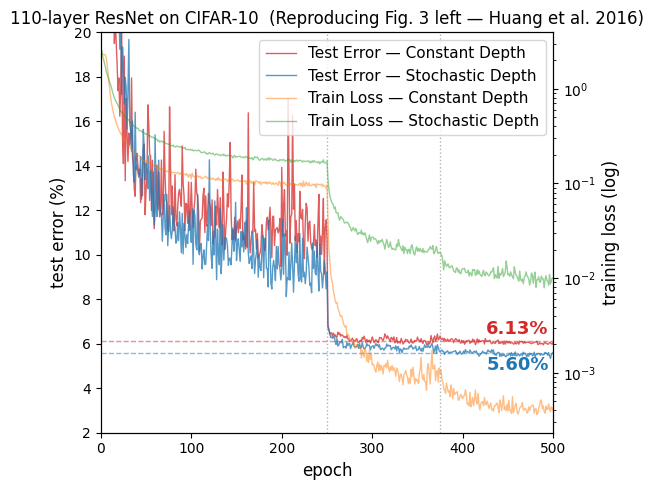

Saved.


In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 5))

ep = range(1, len(h_cd['test_err']) + 1)
RED, BLUE = '#d62728', '#1f77b4'

# Test error (left axis)
ax1.plot(ep, h_cd['test_err'], color=RED,  lw=1, alpha=0.75, label='Test Error — Constant Depth')
ax1.plot(ep, h_sd['test_err'], color=BLUE, lw=1, alpha=0.75, label='Test Error — Stochastic Depth')

# Annotate final best errors
for val, color, va in [(h_cd['best_test'], RED, 'bottom'), (h_sd['best_test'], BLUE, 'top')]:
    ax1.axhline(val, color=color, ls='--', lw=1, alpha=0.5)
    ax1.text(len(ep)*0.99, val + (0.15 if va=='bottom' else -0.15),
             f'{val:.2f}%', ha='right', va=va, color=color, fontsize=13, fontweight='bold')

ax1.set_xlabel('epoch', fontsize=12)
ax1.set_ylabel('test error (%)', fontsize=12)
ax1.set_ylim(2, 20);  ax1.set_xlim(0, EPOCHS)

# Training loss (right axis, log scale)
ax2 = ax1.twinx()
ax2.plot(ep, h_cd['train_loss'], color='#ff7f0e', lw=1, alpha=0.5, label='Train Loss — Constant Depth')
ax2.plot(ep, h_sd['train_loss'], color='#2ca02c', lw=1, alpha=0.5, label='Train Loss — Stochastic Depth')
ax2.set_yscale('log')
ax2.set_ylabel('training loss (log)', fontsize=12)

# Vertical lines at LR drops
for ms in LR_MILESTONES:
    ax1.axvline(ms, color='gray', ls=':', lw=1, alpha=0.6)

lines = (ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0],
         ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1])
ax1.legend(*lines, fontsize=11, loc='upper right')
ax1.set_title('110-layer ResNet on CIFAR-10  (Reproducing Fig. 3 left — Huang et al. 2016)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_left.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

### Error and Training Time Comparison

In [ ]:
def fmt_time(sec):
    h, rem = divmod(int(sec), 3600)
    return f'{h}h {rem//60}m'

cd_sec = h_cd['total_sec'];  sd_sec = h_sd['total_sec']
speedup = (cd_sec - sd_sec) / cd_sec * 100
rel_imp = (h_cd['best_test'] - h_sd['best_test']) / h_cd['best_test'] * 100

print('=' * 58)
print(f"{'TABLE 1 — Test Error on CIFAR-10':^58}")
print('=' * 58)
print(f"{'Method':<28} {'Ours':>10}  {'Paper':>10}")
print('-' * 58)
print(f"{'ResNet-110 (constant depth)':<28} {h_cd['best_test']:>9.2f}%  {'6.41%':>10}")
print(f"{'ResNet-110 (stochastic depth)':<28} {h_sd['best_test']:>9.2f}%  {'5.25%':>10}")
print(f"{'Relative improvement':<28} {rel_imp:>9.1f}%  {'18.1%':>10}")
print()
print('=' * 58)
print(f"{'TABLE 2 — Training Time (500 epochs)':^58}")
print('=' * 58)
print(f"{'Method':<28} {'Ours':>10}  {'Paper':>10}")
print('-' * 58)
print(f"{'Constant Depth':<28} {fmt_time(cd_sec):>10}  {'20h 42m':>10}")
print(f"{'Stochastic Depth':<28} {fmt_time(sd_sec):>10}  {'15h  7m':>10}")
print(f"{'Wall-clock speedup':<28} {speedup:>9.1f}%  {'~25%':>10}")
print('=' * 58)

             TABLE 1 — Test Error on CIFAR-10             
Method                             Ours       Paper
----------------------------------------------------------
ResNet-110 (constant depth)       6.13%       6.41%
ResNet-110 (stochastic depth)      5.60%       5.25%
Relative improvement               8.6%       18.1%

           TABLE 2 — Training Time (500 epochs)           
Method                             Ours       Paper
----------------------------------------------------------
Constant Depth                   2h 51m     20h 42m
Stochastic Depth                 2h 28m     15h  7m
Wall-clock speedup                13.2%        ~25%


### Experiment 2 - Gradient Magnitude Analysis

The paper shows stochastic depth **alleviates vanishing gradients** — gradient magnitudes in early layers remain larger throughout training compared to constant depth.

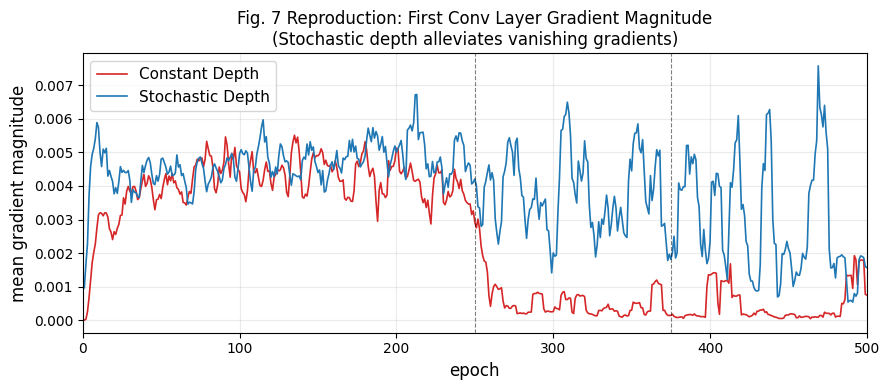

Saved.


In [ ]:
def smooth(arr, w=7):
    kernel = np.ones(w) / w
    return np.convolve(arr, kernel, mode='same')

fig, ax = plt.subplots(figsize=(9, 4))
ep = range(1, len(h_cd['grad_mag']) + 1)

ax.plot(ep, smooth(np.array(h_cd['grad_mag'])), color='#d62728', lw=1.2, label='Constant Depth')
ax.plot(ep, smooth(np.array(h_sd['grad_mag'])), color='#1f77b4', lw=1.2, label='Stochastic Depth')

for ms in LR_MILESTONES:
    ax.axvline(ms, color='black', ls='--', lw=0.8, alpha=0.5)

ax.set_xlabel('epoch', fontsize=12)
ax.set_ylabel('mean gradient magnitude', fontsize=12)
ax.set_title('Fig. 7 Reproduction: First Conv Layer Gradient Magnitude\n'
             '(Stochastic depth alleviates vanishing gradients)', fontsize=12)
ax.legend(fontsize=11);  ax.set_xlim(0, EPOCHS);  ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig7_gradient_magnitude.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

### Setup: Load trained models (skip if models are already in memory)

In [ ]:
# Load best checkpoints from disk if the training cells were run in a previous session
def _load_best(name, model_cls, **kw):
    m = model_cls(**kw).to(device)
    p = os.path.join(SAVE_DIR, name, 'best_model.pth')
    m.load_state_dict(torch.load(p, map_location=device))
    m.eval()
    print(f"  Loaded {name} from {p}")
    return m

try:
    model_cd.eval(); model_sd.eval()
    print("Using in-memory models.")
except NameError:
    print("Loading from disk ...")
    model_cd = _load_best('constant_depth',  ResNet110)
    model_sd = _load_best('stochastic_depth', ResNet110_SD, p_L=P_L)

_criterion = nn.CrossEntropyLoss()

Loading from disk ...
  Loaded constant_depth from /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results/constant_depth/best_model.pth
  Loaded stochastic_depth from /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results/stochastic_depth/best_model.pth


### Experiment 3 — t-SNE Visualization of Learned Representations

Both models have the same architecture and are trained on the same data, but stochastic depth's regularization should push the network to learn **more generalizable, better-separated** features.

**This experiment extracts the 64-dimensional penultimate-layer features** (output of the global average pooling, before the classifier) from 2,000 test images and projects them into 2D using t-SNE.


Extracting penultimate-layer features ...
Running t-SNE (perplexity=40, this takes ~1 min) ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_9370/970862235.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', 10)


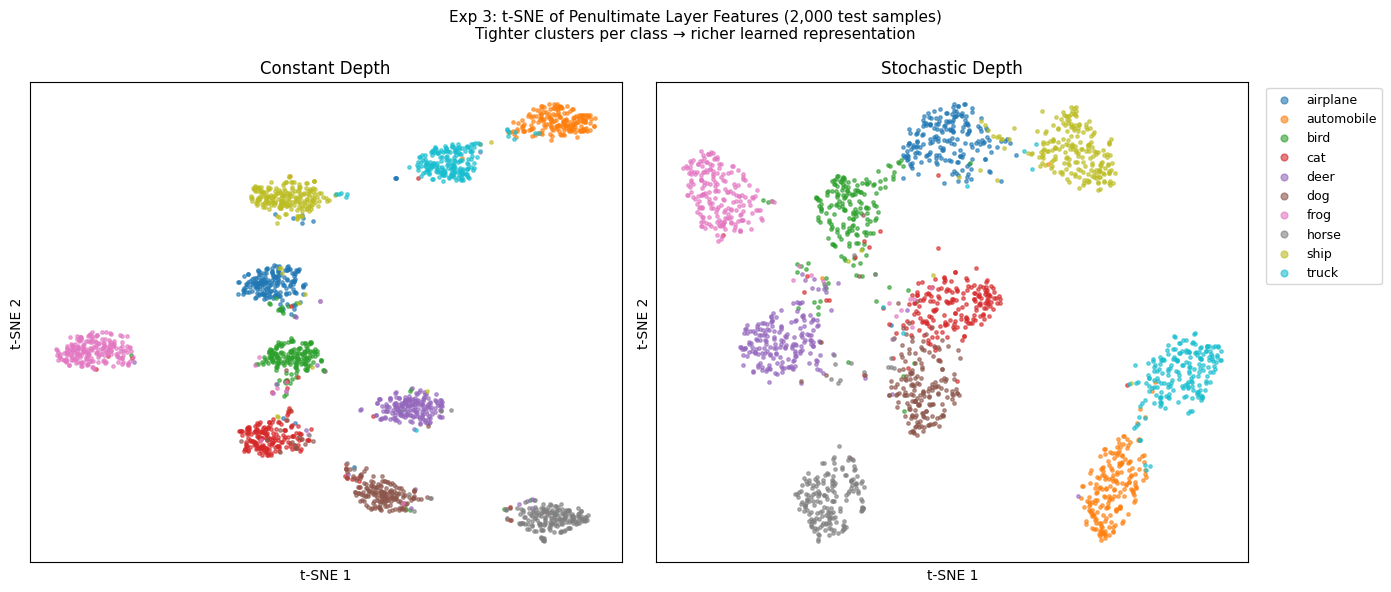

In [ ]:
from sklearn.manifold import TSNE

@torch.no_grad()
def extract_features(model, loader, device, max_n=2000):
    model.eval()
    feats, labels = [], []
    hook_buf = []
    handle = model.pool.register_forward_hook(lambda m, inp, out: hook_buf.append(out.squeeze(-1).squeeze(-1).cpu()))
    for inputs, targets in loader:
        model(inputs.to(device))
        feats.append(hook_buf.pop())
        labels.append(targets)
        if sum(f.size(0) for f in feats) >= max_n:
            break
    handle.remove()
    return torch.cat(feats)[:max_n].numpy(), torch.cat(labels)[:max_n].numpy()


CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Extracting penultimate-layer features ...")
f_cd, l_cd = extract_features(model_cd, test_loader, device)
f_sd, l_sd = extract_features(model_sd, test_loader, device)
print("Running t-SNE (perplexity=40, this takes ~1 min) ...")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=1)
f_all = np.concatenate([f_cd, f_sd], axis=0)
emb_all = tsne.fit_transform(f_all)
emb_cd = emb_all[:len(f_cd)]
emb_sd = emb_all[len(f_cd):]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = plt.cm.get_cmap('tab10', 10)
for ax, emb, lbl, title in zip(
        axes, [emb_cd, emb_sd], [l_cd, l_sd],
        ['Constant Depth', 'Stochastic Depth']):
    for c in range(10):
        mask = lbl == c
        ax.scatter(emb[mask, 0], emb[mask, 1], c=[palette(c)], s=6, alpha=0.6, label=CIFAR10_CLASSES[c])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.set_xticks([]);  ax.set_yticks([])

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, markerscale=2)
fig.suptitle('Exp 3: t-SNE of Penultimate Layer Features (2,000 test samples)\n'
             'Tighter clusters per class → richer learned representation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'exp3_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Exp 3b — Quantitative Representation Quality: Does Tighter t-SNE = Better Features?

The t-SNE plot above shows Constant Depth has visually tighter, more separated clusters yet its test error is *higher* (6.41% vs 5.25%). This raises a key question:

> **Is visual cluster compactness in t-SNE a reliable proxy for representation quality?**

We answer this with three quantitative metrics computed directly in the 64-dimensional feature space
(no 2D distortion):

| Metric | What it measures | Better = |
|--------|-----------------|----------|
| **k-NN Accuracy** | How well raw features classify unseen samples (no learned head) | ↑ Higher |
| **Silhouette Score** | Cluster cohesion vs. separation in 64D (cosine) | ↑ Higher |
| **Intra / Inter-class Distance Ratio** | Compactness within class vs. spread across classes | ↓ Lower |


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, cdist

# intra / inter-class cosine distances
def intra_inter_dist(feats, labels):
    """Returns (mean intra-class dist, mean inter-class dist) in cosine space."""
    F = normalize(feats.astype(np.float32))
    classes = np.unique(labels)
    intra_list, inter_list = [], []
    centers = {c: F[labels == c].mean(0) for c in classes}
    for c in classes:
        cf = F[labels == c]
        if len(cf) > 1:
            intra_list.append(pdist(cf, metric='cosine').mean())
        other_centers = np.stack([centers[o] for o in classes if o != c])
        inter_list.append(cdist(centers[c][None], other_centers, metric='cosine').mean())
    return float(np.mean(intra_list)), float(np.mean(inter_list))


# k-NN accuracy
print("Computing k-NN accuracy in 64-dim feature space ...")
n_gallery = 1500
K_LIST = [1, 5, 10, 20]
knn_res = {}
for label, F, L in [('Constant Depth', f_cd, l_cd), ('Stochastic Depth', f_sd, l_sd)]:
    accs = {}
    for k in K_LIST:
        knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute')
        knn.fit(F[:n_gallery], L[:n_gallery])
        accs[k] = knn.score(F[n_gallery:], L[n_gallery:]) * 100
    knn_res[label] = accs
    print(f"  {label}: " + "  ".join(f"k={k}: {accs[k]:.1f}%" for k in K_LIST))

# Silhouette score in 64D
print("\nComputing Silhouette scores in 64-dim ...")
N_SIL = 600
sil = {}
for label, F, L in [('Constant Depth', f_cd, l_cd),
                     ('Stochastic Depth', f_sd, l_sd)]:
    sil[label] = silhouette_score(F[:N_SIL], L[:N_SIL], metric='cosine')
    print(f"  {label}: {sil[label]:.4f}")

# Intra / inter-class distance ratio
print("\nComputing intra/inter-class distances ...")
dist_res = {}
for label, F, L in [('Constant Depth', f_cd, l_cd), ('Stochastic Depth', f_sd, l_sd)]:
    intra, inter = intra_inter_dist(F, L)
    dist_res[label] = {'intra': intra, 'inter': inter, 'ratio': intra / inter}
    print(f" {label}: intra={intra:.4f}  inter={inter:.4f}  ratio={intra/inter:.4f}")

# Summary table
print()
print("=" * 62)
print(f"{'Quantitative Summary: 64-dim Feature Space':^62}")
print("=" * 62)
cd, sd = 'Constant Depth', 'Stochastic Depth'
print(f"  {'Metric':<32} {cd:>12}  {sd:>12}")
print("-" * 62)
for k in K_LIST:
    winner = '← ✓' if knn_res[sd][k] > knn_res[cd][k] else ''
    print(f"  {f'k-NN acc (k={k})':<32} {knn_res[cd][k]:>11.1f}%  {knn_res[sd][k]:>11.1f}%  {winner}")
print(f"  {'Silhouette score (↑ better)':<32} {sil[cd]:>12.4f}  {sil[sd]:>12.4f}  {'← ✓' if sil[sd] > sil[cd] else ''}")
print(f"  {'Intra/Inter ratio (↓ better)':<32} {dist_res[cd]['ratio']:>12.4f}  {dist_res[sd]['ratio']:>12.4f}  {'← ✓' if dist_res[sd]['ratio'] < dist_res[cd]['ratio'] else ''}")
print("=" * 62)

Computing k-NN accuracy in 64-dim feature space ...
  Constant Depth: k=1: 91.2%  k=5: 93.0%  k=10: 93.0%  k=20: 93.0%
  Stochastic Depth: k=1: 91.4%  k=5: 94.2%  k=10: 94.6%  k=20: 94.4%

Computing Silhouette scores in 64-dim ...
  Constant Depth: 0.6556
  Stochastic Depth: 0.5377

Computing intra/inter-class distances ...
 Constant Depth: intra=0.1267  inter=0.5019  ratio=0.2524
 Stochastic Depth: intra=0.1698  inter=0.4358  ratio=0.3898

          Quantitative Summary: 64-dim Feature Space          
  Metric                           Constant Depth  Stochastic Depth
--------------------------------------------------------------
  k-NN acc (k=1)                          91.2%         91.4%  ← ✓
  k-NN acc (k=5)                          93.0%         94.2%  ← ✓
  k-NN acc (k=10)                         93.0%         94.6%  ← ✓
  k-NN acc (k=20)                         93.0%         94.4%  ← ✓
  Silhouette score (↑ better)            0.6556        0.5377  
  Intra/Inter ratio (↓ better

### Experiment 4 — Label Noise Robustness Experiment

To test whether stochastic depth acts as an effective regularizer, we deliberately corrupt a portion of the training labels by randomly reassigning them to incorrect classes. An overfitting-prone model will memorize these false labels, achieving low training loss but poor test accuracy. A well-regularized model should be more resistant to this memorization. We train both constant-depth and stochastic-depth ResNets under 20%, 40%, and 60% label noise, keeping validation and test labels clean.

In [ ]:
for nl in [0.2, 0.4, 0.6]:
  train_model(
    name=f'constant_depth_{nl}',
    model_cls=ResNet110,
    noise_rate=nl
  )
  train_model(
    name=f'stochastic_depth_{nl}',
    model_cls=ResNet110_SD,
    noise_rate=nl,
    p_L=P_L
  )


Training: constant_depth_0.2
Corrupted 9000/45000 training labels (20%)
Train: 45,000 | Val: 5,000 | Test: 10,000
Resuming from /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results/constant_depth_0.2/checkpoint.pth
Resumed at epoch 501

  constant_depth_0.2 done! best_val=16.68%  best_test=15.91%  total_time=3h 2m

Training: stochastic_depth_0.2
Corrupted 9000/45000 training labels (20%)
Train: 45,000 | Val: 5,000 | Test: 10,000
Resuming from /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results/stochastic_depth_0.2/checkpoint.pth
Resumed at epoch 501

  stochastic_depth_0.2 done! best_val=10.44%  best_test=9.92%  total_time=2h 37m

Training: constant_depth_0.4
Corrupted 18000/45000 training labels (40%)
Train: 45,000 | Val: 5,000 | Test: 10,000
Resuming from /content/drive/MyDrive/ColabNotebooks/CS5482 final project/stochastic_depth_results/constant_depth_0.4/checkpoint.pth
Resumed at epoch 501

  constant_depth_0.4 done! b

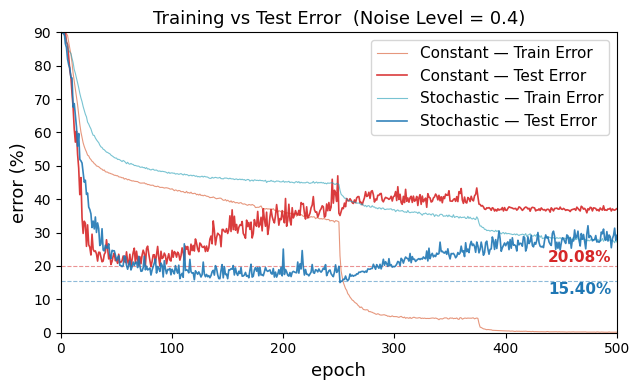

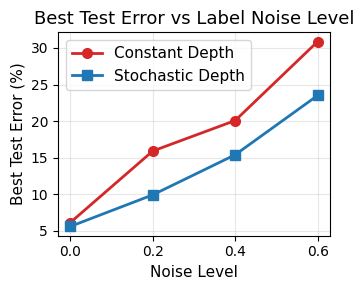

Saved.


In [ ]:
noise_levels = [0.0, 0.2, 0.4, 0.6]

h_cd2 = load_history('constant_depth_0.2')
h_sd2 = load_history('stochastic_depth_0.2')
h_cd4 = load_history('constant_depth_0.4')
h_sd4 = load_history('stochastic_depth_0.4')
h_cd6 = load_history('constant_depth_0.6')
h_sd6 = load_history('stochastic_depth_0.6')

# Figure: noise level = 0.4, training & test error over epochs
ep = range(1, len(h_cd4['test_err']) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
for val, color, va in [(h_cd4['best_test'], RED, 'bottom'), (h_sd4['best_test'], BLUE, 'top')]:
    ax.axhline(val, color=color, ls='--', lw=0.8, alpha=0.5)
    ax.text(len(ep)*0.99, val + (0.15 if va=='bottom' else -0.15),
             f'{val:.2f}%', ha='right', va=va, color=color, fontsize=11, fontweight='bold')

ax.plot(ep, h_cd4['train_err'], color='#d65227', lw=0.8, alpha=0.6, label='Constant — Train Error')
ax.plot(ep, h_cd4['test_err'],  color='#d62728', lw=1.2, alpha=0.9, label='Constant — Test Error')
ax.plot(ep, h_sd4['train_err'], color='#1f9cb4', lw=0.8, alpha=0.6, label='Stochastic — Train Error')
ax.plot(ep, h_sd4['test_err'],  color='#1f77b4', lw=1.2, alpha=0.9, label='Stochastic — Test Error')

ax.set_xlabel('epoch', fontsize=13)
ax.set_ylabel('error (%)', fontsize=13)
ax.set_ylim(0, 90);  ax.set_xlim(0, EPOCHS)

ax.legend(fontsize=11, loc='upper right')
ax.set_title('Training vs Test Error  (Noise Level = 0.4)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'overfitting_curves_noise_0.4.png'), dpi=150, bbox_inches='tight')
plt.show()

# Fig 2: Best test error over noise levels
cd_best = [h_cd['best_test'], h_cd2['best_test'], h_cd4['best_test'], h_cd6['best_test']]
sd_best = [h_sd['best_test'], h_sd2['best_test'], h_sd4['best_test'], h_sd6['best_test']]

fig, ax = plt.subplots(figsize=(3.5, 3))
ax.plot(noise_levels, cd_best, 'o-', color='#d62728', lw=2, ms=7, label='Constant Depth')
ax.plot(noise_levels, sd_best, 's-', color='#1f77b4', lw=2, ms=7, label='Stochastic Depth')

ax.set_xlabel('Noise Level', fontsize=11)
ax.set_ylabel('Best Test Error (%)', fontsize=11)
ax.set_title('Best Test Error vs Label Noise Level', fontsize=13)
ax.set_xticks(noise_levels)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'best_test_error_vs_noise.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Saved.")